<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%9E%D0%B1%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%BA%D0%B0_%D0%B2%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D1%85_%D1%80%D1%8F%D0%B4%D0%BE%D0%B2_%D1%81_%D0%BF%D0%BE%D0%BC%D0%BE%D1%89%D1%8C%D1%8E_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9_%7C_%D0%94%D0%97_Lite_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Используя базу курса акций Лукойла, необходимо обучить две простые полносвязные нейронные сети. Первая сеть будет прогнозировать значение временного ряда (только close), вторая — предсказывать его на 10 шагов вперёд прямым способом.**

1.После обучения сетей нужно визуализировать результаты их работы.
2.Построить графики сравнения предсказаний с оригинальным сигналом по всем 10 шагам для каждой из сетей.
3.Всего должно получиться 10 графиков на разных осях.

4.Для выполнения задания можно использовать разные архитектуры нейронных сетей, например, добавить в них слои Conv1D или LSTM.

## Подготовка данных

Загрузка библиотек

In [1]:
# Работа с массивами
import numpy as np

# Работа с таблицами
import pandas as pd

# Классы-конструкторы моделей нейронных сетей
from tensorflow.keras.models import Sequential, Model

# Основные слои
from tensorflow.keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, LSTM

# Оптимизаторы
from tensorflow.keras.optimizers import Adam

# Генератор выборки временных рядов
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Нормировщики
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Загрузка датасетов из облака google
import gdown

# Отрисовка графиков
import matplotlib.pyplot as plt

# Отрисовка графики в ячейке colab
%matplotlib inline

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Назначение размера и стиля графиков по умолчанию
from pylab import rcParams
plt.style.use('ggplot')
rcParams['figure.figsize'] = (14, 7)

Загрузка базы

In [3]:
# Загрузка датасетов из облака

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/16_17.csv', None, quiet=True)
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/18_19.csv', None, quiet=True)

'18_19.csv'

In [4]:
# Чтение данных в таблицу pandas
base_data = pd.read_csv('18_19.csv', sep=';')

In [5]:
# Вывод первых строк таблицы
base_data.head()

,DATE,TIME,OPEN,MAX,MIN,CLOSE,VOLUME
0,03.01.2018,10:00:00,3341.0,3356.0,3340.0,3355.0,6088
1,03.01.2018,10:01:00,3355.0,3359.0,3353.0,3353.0,1624
2,03.01.2018,10:02:00,3351.5,3357.5,3351.5,3357.5,722
3,03.01.2018,10:03:00,3354.5,3360.0,3354.5,3358.0,3034
4,03.01.2018,10:04:00,3358.0,3360.0,3351.5,3360.0,1427


In [6]:
# Загрузка датасетов с удалением ненужных столбцов по дате и времени

data16_17 = pd.read_csv('16_17.csv', sep=';').drop(columns=['DATE', 'TIME'])
data18_19 = pd.read_csv('18_19.csv', sep=';').drop(columns=['DATE', 'TIME'])

In [7]:
# Просмотр размерностей получившихся табли

print(data16_17.shape)
print(data18_19.shape)

(263925, 5)
(217947, 5)


In [8]:
# Пример данных одного датасета
d = data18_19

print(d.shape[0])  # Всего записей (строк)
print(d.shape[1])  # Количество столбцов
print(d.iloc[0])   # Пример нулевой строки данных

217947
5
OPEN      3341.0
MAX       3356.0
MIN       3340.0
CLOSE     3355.0
VOLUME    6088.0
Name: 0, dtype: float64


In [9]:
# Создание общего набора данных из двух датасетов

data = pd.concat([data16_17, data18_19]).to_numpy()

In [10]:
# Просмотр размерности новой таблицы

print(data16_17.shape)
print(data18_19.shape)
print(data.shape)

(263925, 5)
(217947, 5)
(481872, 5)


In [11]:
# Задание текстовых меток каналов данных (столбцов)

CHANNEL_NAMES = ['Open', 'Max', 'Min', 'Close', 'Volume']
CHANNEL_INDEX = {name: chan for chan, name in enumerate(CHANNEL_NAMES)}

Иллюстрация данных в графическом виде

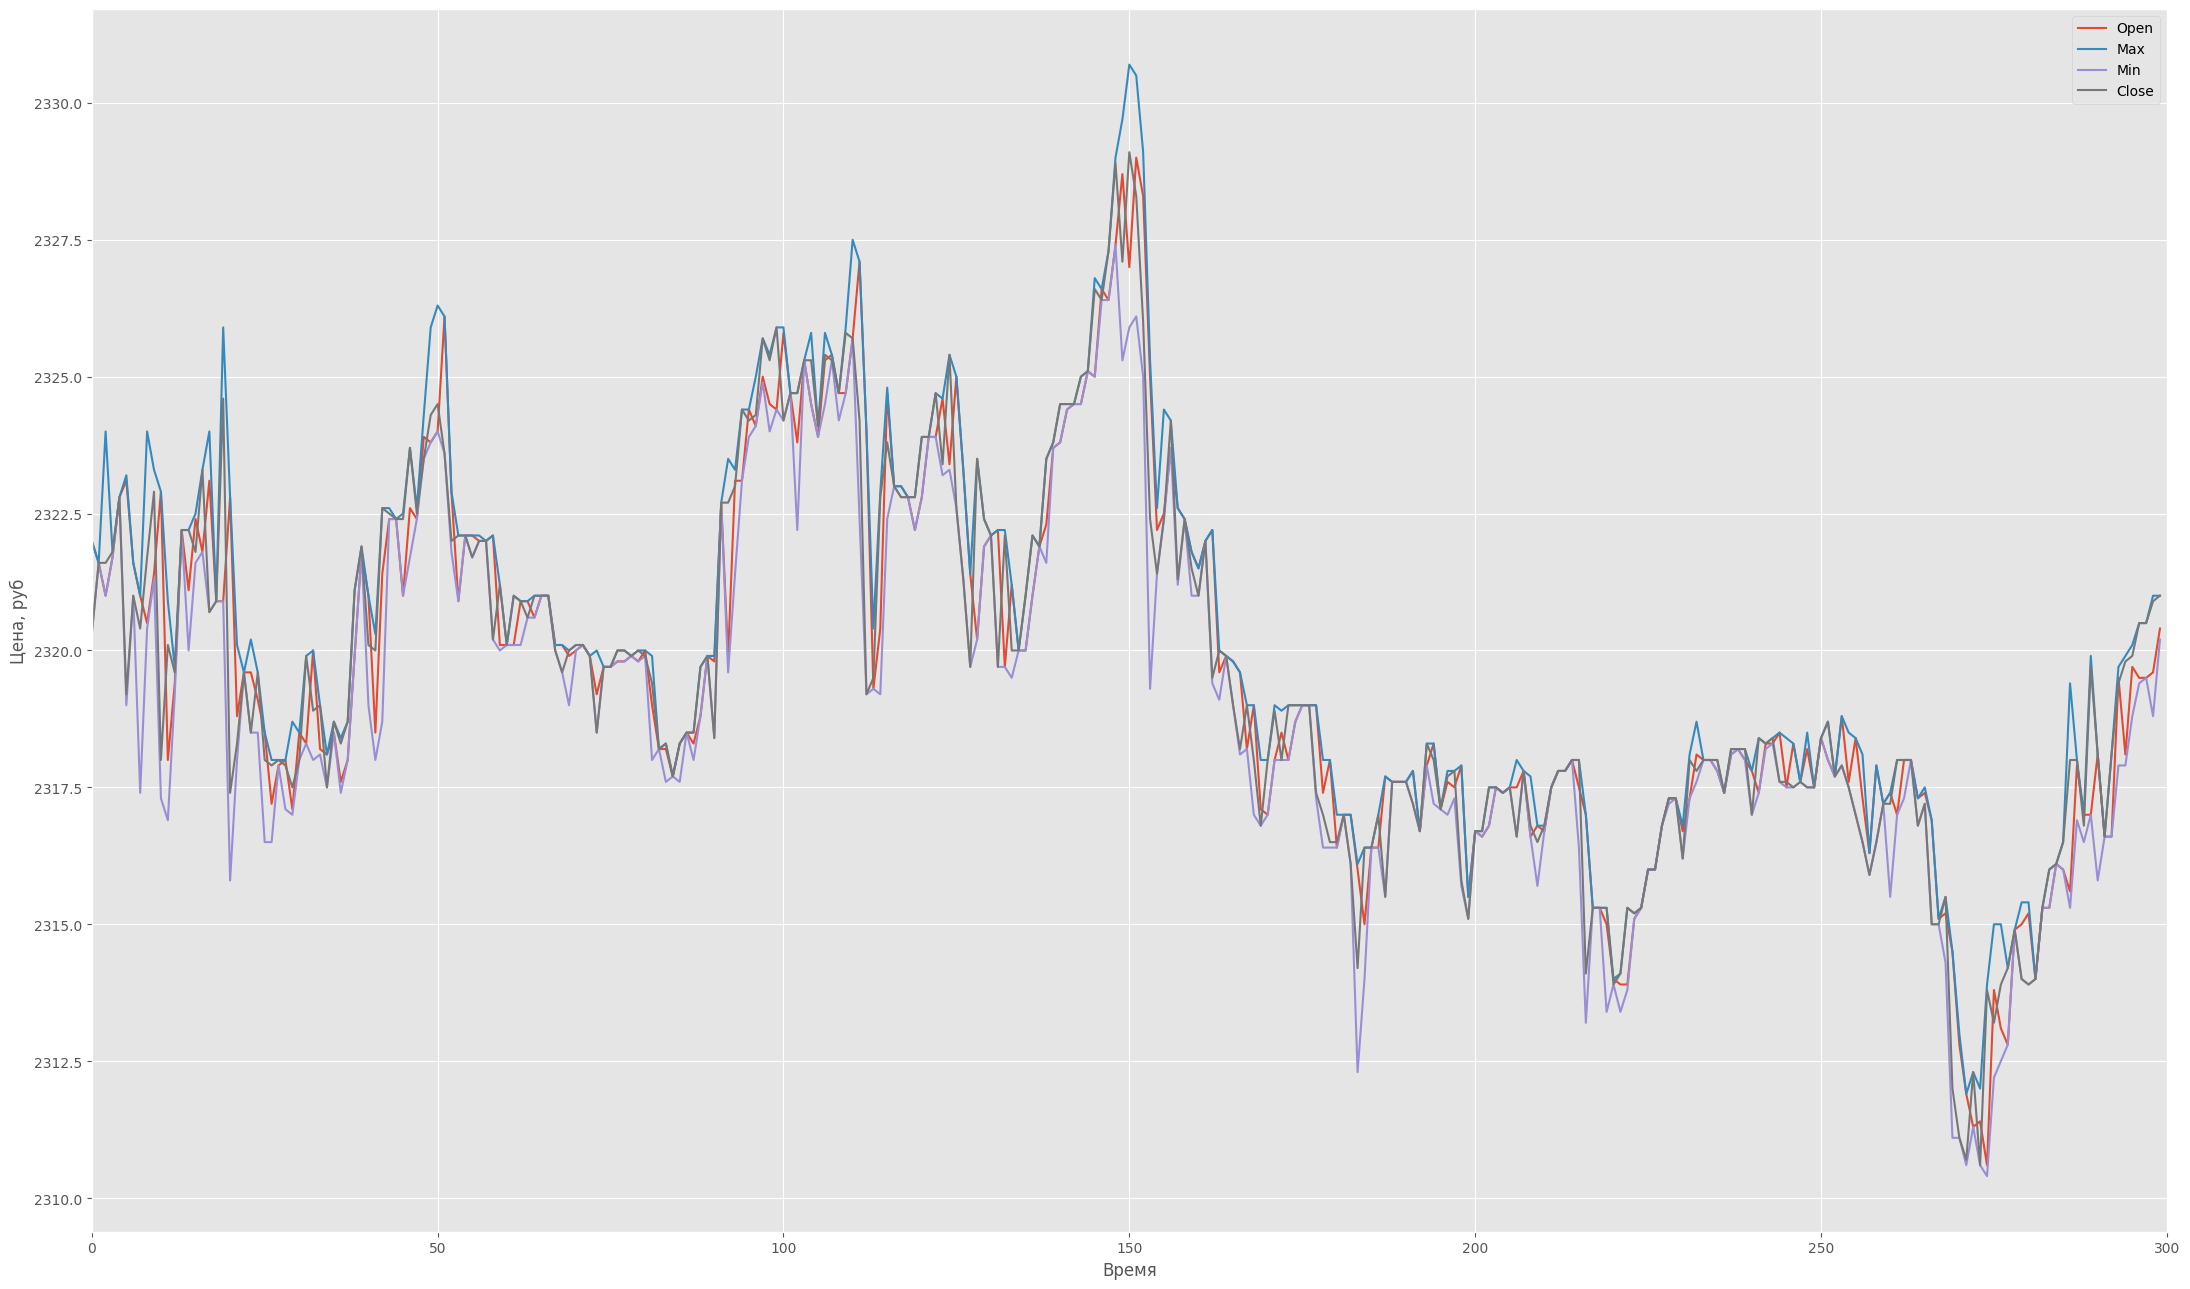

In [12]:
# Отображение исходных данных от точки start и длинной length
start = 100
length = 300

# Задание полотна для графиков - два подграфика один под другим с общей осью x
fig, ax = plt.subplots(figsize=(22, 13), sharex=True)

# Четыре основных канала - open, max, min, close
for chn in range(4):
    # Отрисовка одного канала данных
    # От начальной точки start длиной length
    ax.plot(data[start:start + length, chn],
             label=CHANNEL_NAMES[chn])
ax.set_ylabel('Цена, руб')
ax.legend()
plt.xlabel('Время')

# Регулировка пределов оси x
plt.xlim(0, length)

# Указание расположить подграфики плотнее друг к другу
plt.tight_layout()

# Фиксация графика
plt.show()

In [13]:
#Ваше решение

# Задание гиперпараметров

CHANNEL_X = CHANNEL_NAMES                 # Отбор каналов входных данных
CHANNEL_Y = ['Close']                     # Отбор каналов данных для предсказания
SEQ_LEN = 300                             # Длина прошедших данных для анализа
BATCH_SIZE = 20                           # Объем батча для генератора
TEST_LEN = 30000                          # Объем тестовой выборки
TRAIN_LEN = data.shape[0] - TEST_LEN      # Объем обучающей выборки

In [27]:
# Формирование списков индексов каналов данных для входных и выходных выборок
chn_x = [CHANNEL_INDEX[c] for c in CHANNEL_X]
chn_y = [CHANNEL_INDEX[c] for c in CHANNEL_Y]

# Проверка результата
print(chn_x, chn_y)

# Разделение данных на тренировочный и тестовый наборы
# 2*SEQ_LEN - для разрыва между тренировочными и тестовыми данными
# варьируемый параметр, страховка от пересечения
data_train, data_test = data[:TRAIN_LEN], data[TRAIN_LEN + 2*SEQ_LEN:]

# Отбор входных данных
x_data_train, x_data_test = data_train[:, chn_x], data_test[:, chn_x]

# Масштабирование данных
x_scaler = MinMaxScaler()
x_scaler.fit(x_data_train)
x_data_train = x_scaler.transform(x_data_train)
x_data_test = x_scaler.transform(x_data_test)

# Отбор выходных данных
y_data_train, y_data_test = data_train[:, chn_y], data_test[:, chn_y]
# для предсказания на 10 шагов вперед
y_data_train_10 = [y_data_train[i:i + 10].tolist() for i in range(y_data_train.shape[0])]
y_data_test_10 = [y_data_test[i:i + 10].tolist() for i in range(y_data_test.shape[0])]
y_data_train_10 = np.array(y_data_train_10[:-10])
y_data_test_10 = np.array(y_data_test_10[:-10])
y_data_train_10 = y_data_train_10.reshape((y_data_train_10.shape[0], 10))
y_data_test_10 = y_data_test_10.reshape((y_data_test_10.shape[0], 10))
print(y_data_train_10[:5])
# Масштабирование данных
y_scaler = MinMaxScaler()
y_scaler.fit(y_data_train)
y_data_train = y_scaler.transform(y_data_train)
y_data_test = y_scaler.transform(y_data_test)
y_scaler_10 = MinMaxScaler()
print(y_data_train_10.shape)
y_scaler_10.fit(y_data_train_10)
y_data_train_10 = y_scaler_10.transform(y_data_train_10)
y_data_test_10 = y_scaler_10.transform(y_data_test_10)

# Проверка формы данных
print(f'Train data: {x_data_train.shape}, {y_data_train.shape}')
print(f'Test  data: {x_data_test.shape}, {y_data_test.shape}')

# Создание генератора для обучения
train_datagen = TimeseriesGenerator(x_data_train,
                                    y_data_train,
                                    length=SEQ_LEN,
                                    stride=1,
                                    sampling_rate=1,
                                    batch_size=BATCH_SIZE)

# Аналогичный генератор для валидации при обучении
val_datagen = TimeseriesGenerator(x_data_test,
                                  y_data_test,
                                  length=SEQ_LEN,
                                  stride=1,
                                  sampling_rate=1,
                                  batch_size=BATCH_SIZE)



# Проверка формы выдаваемого генератором результата
print(f'Train batch x: {train_datagen[0][0].shape}, y: {train_datagen[0][1].shape}')

[0, 1, 2, 3, 4] [3]
[[2350.  2355.7 2354.1 2353.7 2353.6 2350.  2347.9 2348.3 2348.9 2349.6]
 [2355.7 2354.1 2353.7 2353.6 2350.  2347.9 2348.3 2348.9 2349.6 2349.5]
 [2354.1 2353.7 2353.6 2350.  2347.9 2348.3 2348.9 2349.6 2349.5 2347.3]
 [2353.7 2353.6 2350.  2347.9 2348.3 2348.9 2349.6 2349.5 2347.3 2347.5]
 [2353.6 2350.  2347.9 2348.3 2348.9 2349.6 2349.5 2347.3 2347.5 2346. ]]
(451862, 10)
Train data: (451872, 5), (451872, 1)
Test  data: (29400, 5), (29400, 1)
Train batch x: (20, 300, 5), y: (20, 1)


In [28]:
# Генератор тестовой выборки, генерирует один батч на всю выборку
test_datagen = TimeseriesGenerator(x_data_test,
                                   y_data_test,
                                   length=SEQ_LEN,
                                   stride=1,
                                   sampling_rate=1,
                                   batch_size=x_data_test.shape[0])

# Формирование тестовой выборки из генератора
x_test, y_test = test_datagen[0]

# Проверка формы тестовой выборки
print(f'Test x: {x_test.shape}, y: {y_test.shape}')

Test x: (29100, 300, 5), y: (29100, 1)


In [29]:
#Опишем сервисные функции, которые упростят дальнейшие эксперименты с архитектурами НС:
# Функция расчета результата прогнозирования сети (предсказания)

def get_pred(model, # модель
             x_test, y_test, # тестовая выборка
             y_scaler): # масштабирующий объект для y

    # Вычисление и деномализация предсказания
    y_pred_unscaled = y_scaler.inverse_transform(model.predict(x_test))

    # Денормализация верных ответов
    y_test_unscaled = y_scaler.inverse_transform(y_test)

    # Возврат результата предсказания и верные ответы в исходном масштабе
    return y_pred_unscaled, y_test_unscaled

# Функция расчета корреляционного коэффициента Пирсона для двух рядов

def correlate(a, b):
    return np.corrcoef(a, b)[0, 1]

# Функция визуализации результата предсказания сети и верных ответов

def show_predict(y_pred, y_true, # прогноз данных и исходный ряд
                 start, # точка ряда, с которой начинается отрисовка графика
                 length, # количество точек для отрисовки графика
                 chn_list=None, # список каналов данных для отрисовки (по умолчанию все)
                 chn_names=CHANNEL_Y, # список имен каналов данных
                 title=''):

    # Если список каналов пуст - отображаются все каналы
    if not chn_list:
        chn_list = list(range(y_true.shape[1]))

    # Построение графика по всем каналам данных
    plt.figure(figsize=(22, 6))

    for chn in chn_list:
        plt.plot(y_pred[start:start + length, chn],
                label=f'{chn_names[chn]} Прогноз')
        plt.plot(y_true[start:start + length, chn],
                label=f'{chn_names[chn]} Базовый')

    plt.title(title)
    plt.xlabel('Время')
    plt.ylabel('Данные')
    plt.legend()
    plt.show()

# Функция рисования корреляций прогнозного ряда и исходного со смещением

def show_corr(y_pred, y_true, # прогноз данных и исходный ряд
              back_steps_max=30, # максимальное количество шагов смещения назад по времени
              chn_list=None, # список каналов данных для отрисовки (по умолчанию все)
              chn_names=CHANNEL_Y,
              title=''): # список имен каналов данных

    # Если список каналов пуст - отображаются все каналы
    if not chn_list:
        chn_list = list(range(y_true.shape[1]))

    y_len = y_true.shape[0]
    steps = range(0, back_steps_max + 1)

    # Построение графика по всем каналам данных
    plt.figure(figsize=(14, 7))

    for chn in chn_list:
        # Вычисление коэффициентов корреляции базового ряда и предсказания с разным смещением
        cross_corr = [correlate(y_true[:y_len - step, chn], y_pred[step:, chn]) for step in steps]
        # Вычисление коэффициентов автокорреляции базового ряда с разным смещением
        auto_corr = [correlate(y_true[:y_len - step, chn], y_true[step:, chn]) for step in steps]

        plt.plot(cross_corr, label=f'{chn_names[chn]} Прогноз')
        plt.plot(auto_corr, label=f'{chn_names[chn]} Эталон')

    plt.title(title)

    # Назначение меток шкалы оси x
    plt.xticks(steps)
    plt.xlabel('Шаги смещения')
    plt.ylabel('Коэффициент корреляции')
    plt.legend()
    plt.show()

# Функция визуализации результата работы сети

def eval_net(model, # модель
             x_test, y_test, # тестовая выборка
             y_scaler, # нормировщик выхода
             start=0, length=500, back_steps_max=30, # параметры отображения графиков
             title=''):

    # Получение денормализованного предсказания и данных базового ряда
    y_pred, y_true = get_pred(model, x_test, y_test, y_scaler)

    # Отрисовка графика сопоставления базового и прогнозного рядов
    # Прогнозный ряд сдвигается на 1 шаг назад, так как предсказание делалось на 1 шаг вперед
    show_predict(y_pred[1:], y_true[:-1], start, length,
                 title=f'{title}: Сопоставление базового и прогнозного рядов')
    # Отрисовка графика корреляционных коэффициентов до заданного максимума шагов смещения
    show_corr(y_pred, y_true, back_steps_max=back_steps_max,
              title=f'{title}: Корреляционные коэффициенты по шагам смещения')


In [30]:
# Функция обучения модели и отрисовки прогресса и оценки результатов

def train_eval_net(model, # модель
                   train_datagen, val_datagen, # генераторы обучающей и проверочной выборок
                   epoch_list, # список эпох в виде [(epochs1, opt1), (epochs2, opt2), ...]
                   x_test, y_test,
                   y_scaler,
                   start=0,
                   length=500,
                   back_steps_max=30,
                   title=''):

    # Отображение сводки модели
    model.summary()

    # Обучение модели в несколько фаз в соответствии со списком epoch_list
    for epochs, opt in epoch_list:
        # Компиляция модели
        model.compile(loss='mse', optimizer=opt)
        # Фаза обучения модели
        print(f'Обучение {epochs} эпох')
        history = model.fit(train_datagen,
                            epochs=epochs,
                            validation_data=val_datagen,
                            verbose=1)

        # Рисование графиков прошедшей фазы обучения
        fig = plt.figure(figsize=(14, 7))
        plt.plot(history.history['loss'], label='Ошибка на обучающем наборе')
        plt.plot(history.history['val_loss'], label='Ошибка на проверочном наборе')
        plt.title(f'{title}: График прогресса обучения')
        # Указание показывать только целые метки шкалы оси x
        fig.gca().xaxis.get_major_locator().set_params(integer=True)
        plt.xlabel('Эпоха обучения')
        plt.ylabel('Средняя ошибка')
        plt.legend()
        plt.show()

        # Рисование графиков оценки результата работы модели после фазы обучения
        eval_net(model, x_test, y_test, y_scaler, start=start,
                 length=length, back_steps_max=back_steps_max, title=title)

In [31]:
# Простая полносвязная сеть
model_dense = Sequential()
model_dense.add(Dense(150, input_shape=x_test.shape[1:], activation='relu'))
model_dense.add(Flatten())
model_dense.add(Dense(y_test.shape[1], activation='linear'))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300, 150)       │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 45000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        45,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,901 (179.30 KB)

 Trainable params: 45,901 (179.30 KB)

 Non-trainable params: 0 (0.00 B)

Обучение 50 эпох
Epoch 1/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 60s 3ms/step - loss: 0.0018 - val_loss: 3.5603e-04
Epoch 2/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - loss: 1.0132e-04 - val_loss: 3.2859e-04
Epoch 3/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - loss: 4.2427e-05 - val_loss: 2.1078e-05
Epoch 4/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 59s 3ms/step - loss: 2.8552e-05 - val_loss: 1.6458e-04
Epoch 5/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 58s 3ms/step - loss: 2.6994e-05 - val_loss: 2.1003e-05
Epoch 6/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 58s 3ms/step - loss: 2.2274e-05 - val_loss: 3.7342e-05
Epoch 7/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 80s 2ms/step - loss: 2.0047e-05 - val_loss: 1.1220e-05
Epoch 8/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 59s 3ms/step - loss: 1.8951e-05 - val_loss: 9.6706e-06
Epoch 9/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - loss: 1.6821e-05 - val_loss: 1.2853e-05
Epoch 10/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - loss: 1.4610e-05 - val_loss: 8.4977e

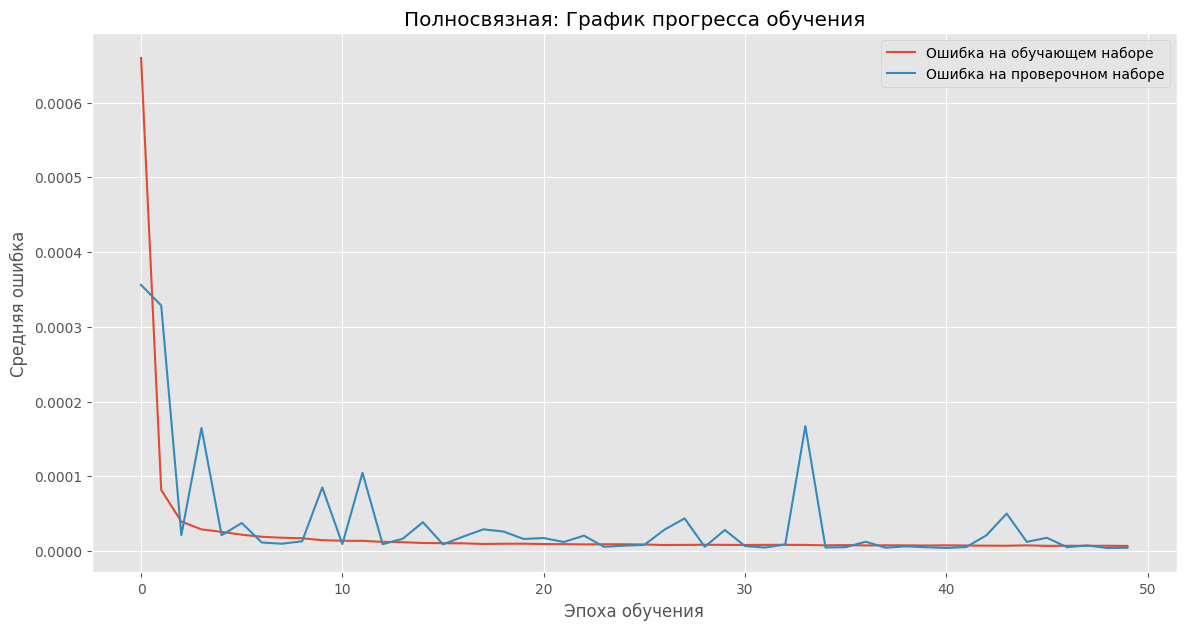

910/910 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


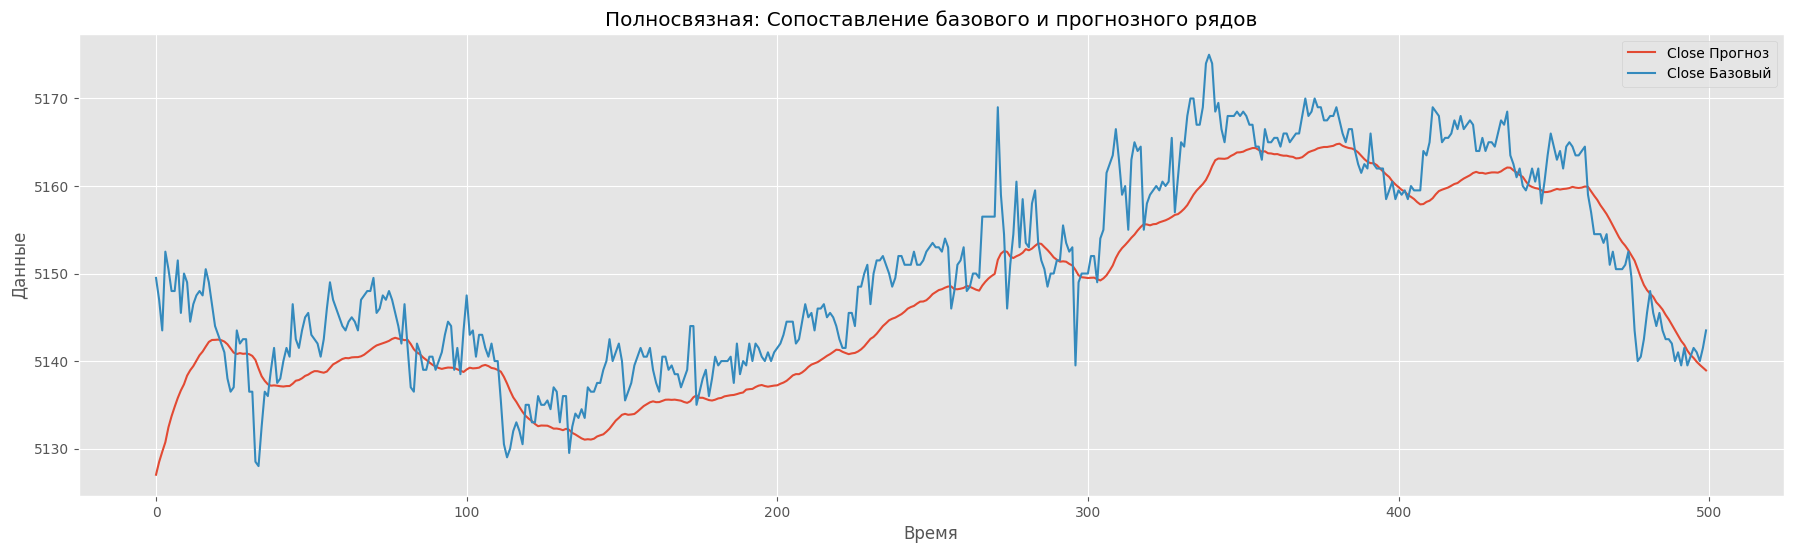

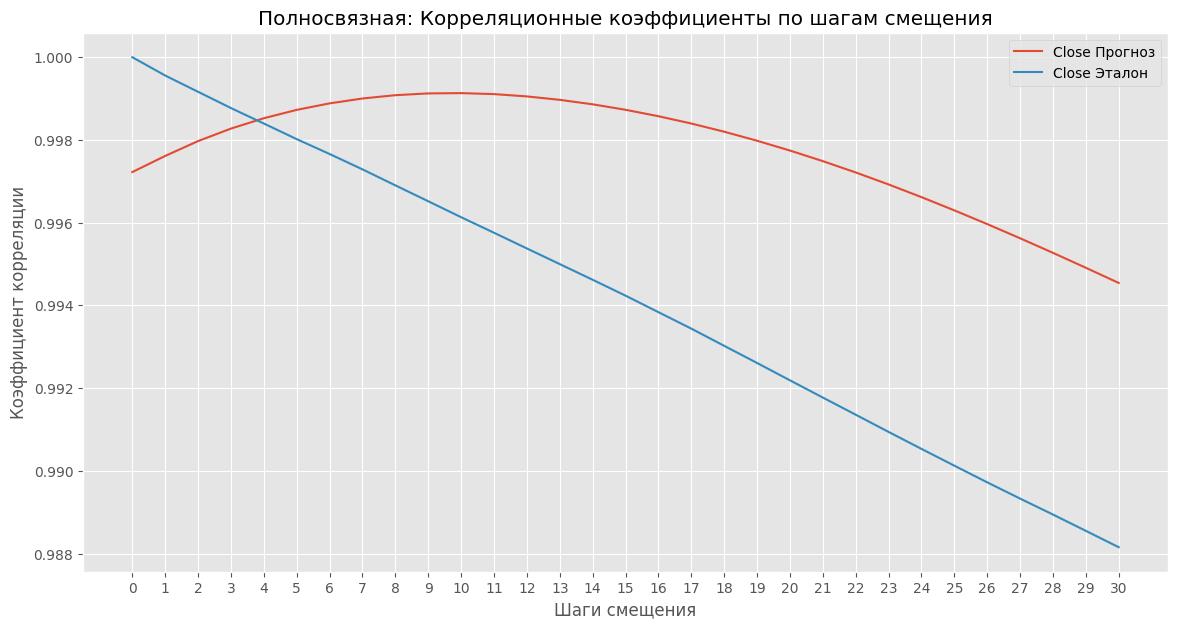

Обучение 50 эпох
Epoch 1/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 60s 3ms/step - loss: 2.6255e-06 - val_loss: 4.3514e-06
Epoch 2/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 58s 3ms/step - loss: 2.5513e-06 - val_loss: 3.4936e-06
Epoch 3/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 60s 3ms/step - loss: 2.3845e-06 - val_loss: 4.6766e-06
Epoch 4/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 83s 3ms/step - loss: 2.4549e-06 - val_loss: 3.5831e-06
Epoch 5/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 81s 3ms/step - loss: 2.4928e-06 - val_loss: 5.9301e-06
Epoch 6/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 60s 3ms/step - loss: 2.4806e-06 - val_loss: 4.7123e-06
Epoch 7/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 62s 3ms/step - loss: 2.4417e-06 - val_loss: 3.4443e-06
Epoch 8/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 59s 3ms/step - loss: 2.5377e-06 - val_loss: 3.3986e-06
Epoch 9/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 84s 3ms/step - loss: 2.4526e-06 - val_loss: 3.7175e-06
Epoch 10/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 61s 3ms/step - loss: 2.4464e-06 - val_loss: 3.6

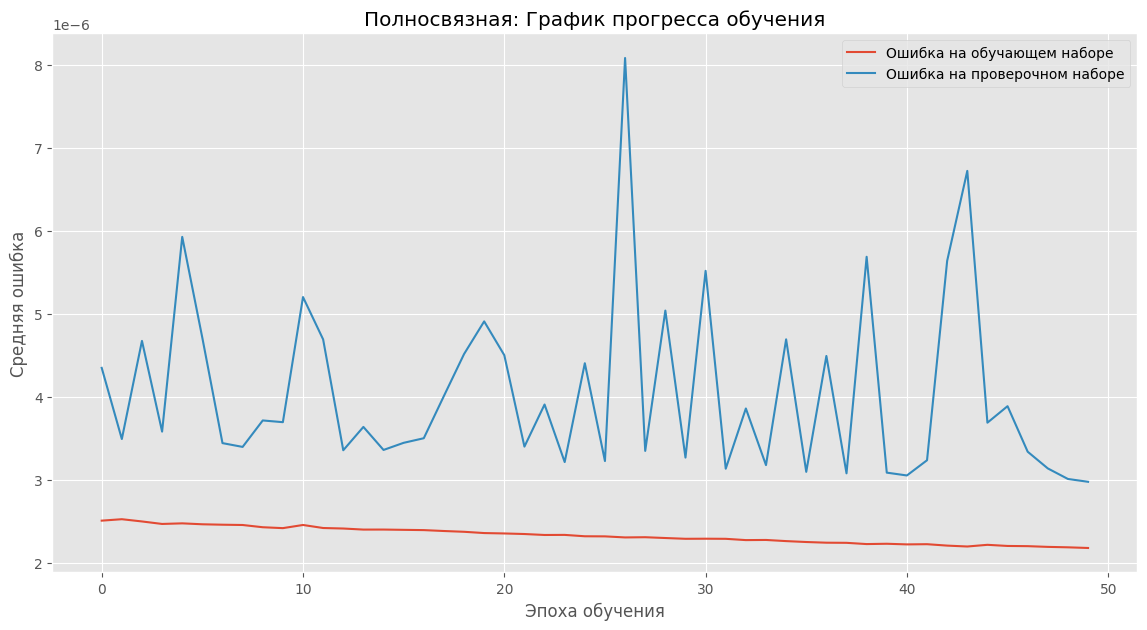

910/910 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


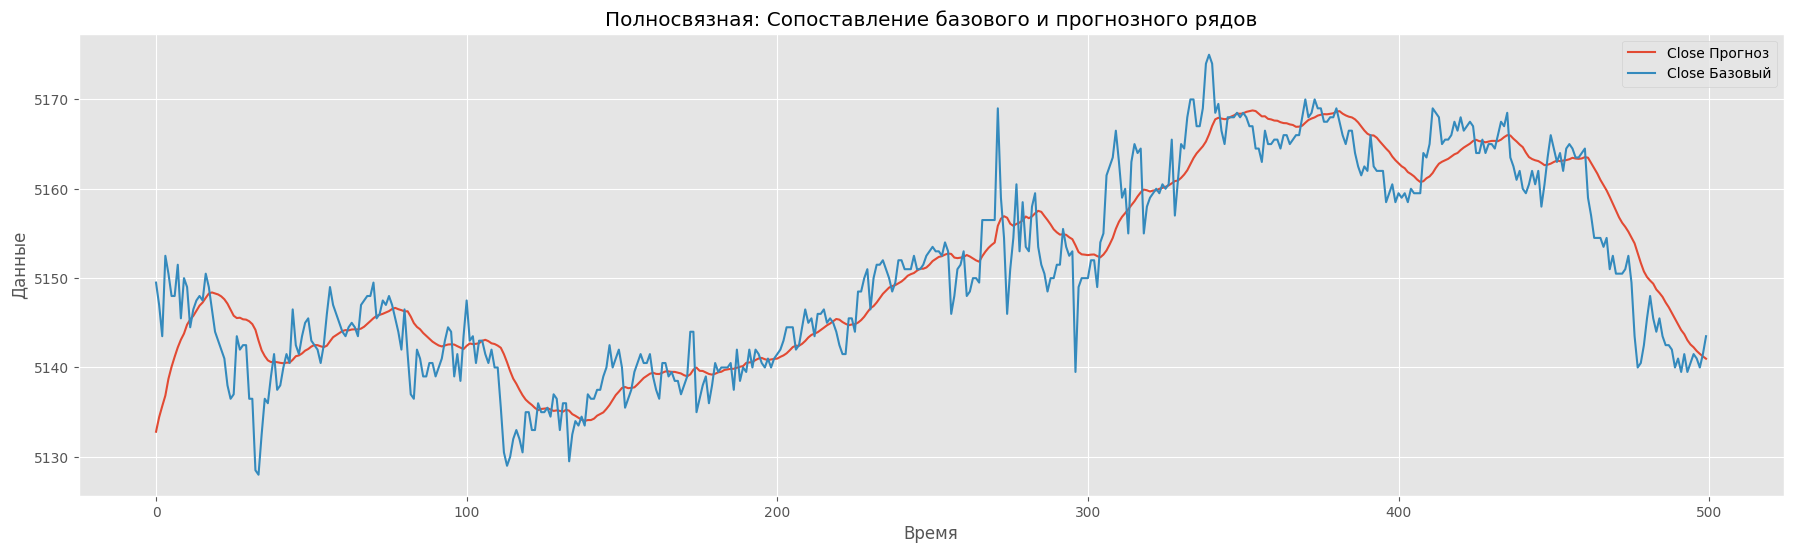

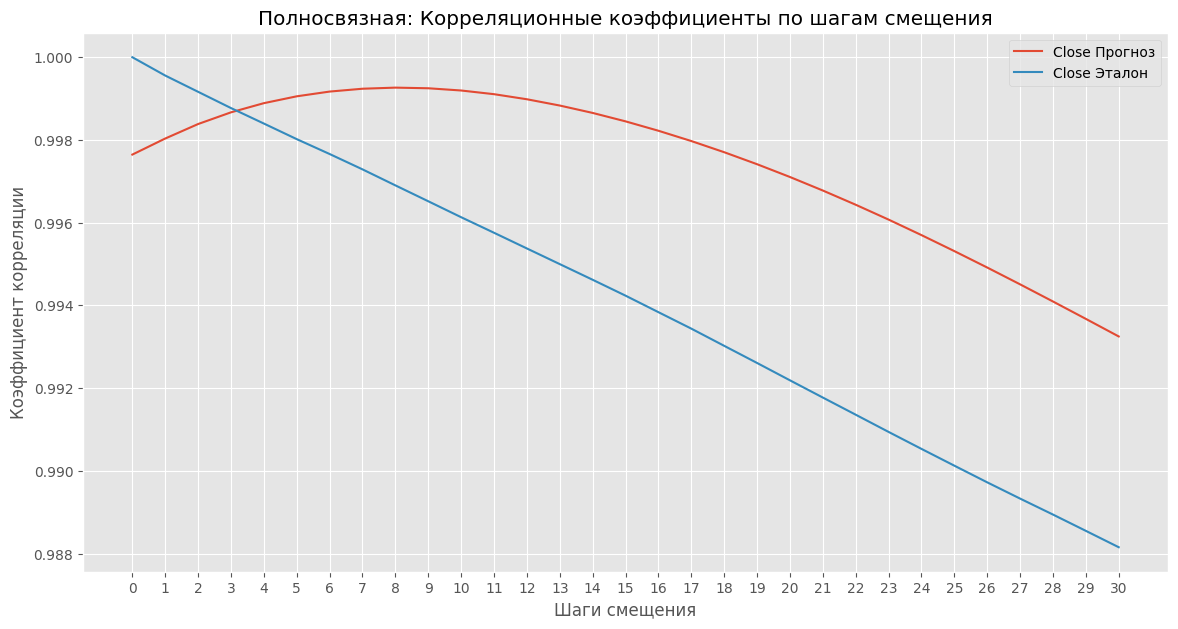

Обучение 50 эпох
Epoch 1/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 64s 3ms/step - loss: 1.9601e-06 - val_loss: 2.9773e-06
Epoch 2/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 60s 3ms/step - loss: 2.0758e-06 - val_loss: 3.0227e-06
Epoch 3/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 62s 3ms/step - loss: 1.9381e-06 - val_loss: 2.9712e-06
Epoch 4/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 79s 3ms/step - loss: 1.9185e-06 - val_loss: 3.0128e-06
Epoch 5/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 60s 3ms/step - loss: 1.9131e-06 - val_loss: 2.9696e-06
Epoch 6/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 84s 3ms/step - loss: 1.9262e-06 - val_loss: 3.0007e-06
Epoch 7/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 60s 3ms/step - loss: 1.9691e-06 - val_loss: 2.9713e-06
Epoch 8/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 59s 3ms/step - loss: 1.9086e-06 - val_loss: 3.0519e-06
Epoch 9/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 86s 3ms/step - loss: 1.9399e-06 - val_loss: 2.9683e-06
Epoch 10/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 61s 3ms/step - loss: 1.8969e-06 - val_loss: 2.9

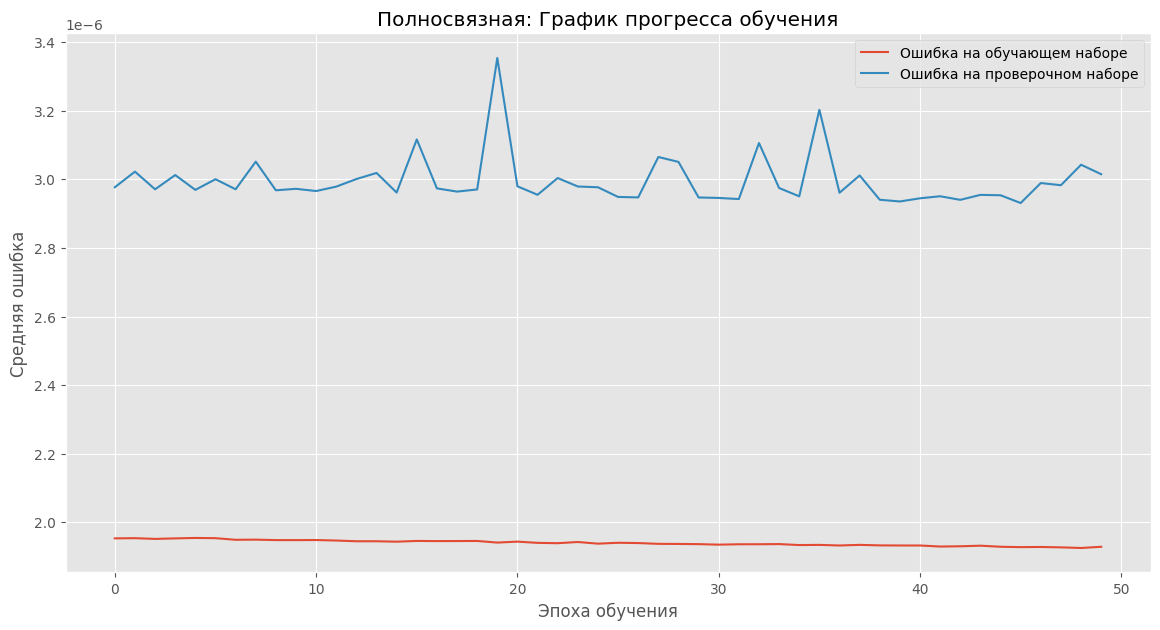

910/910 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


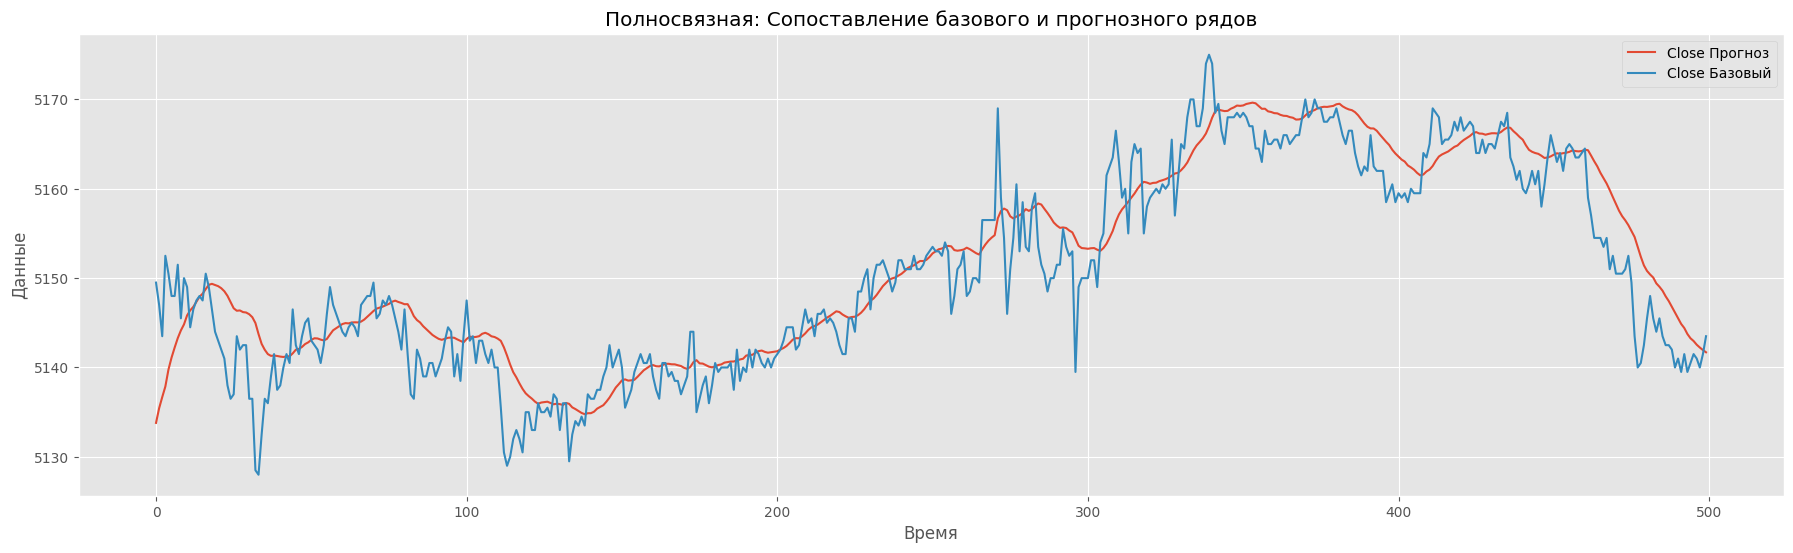

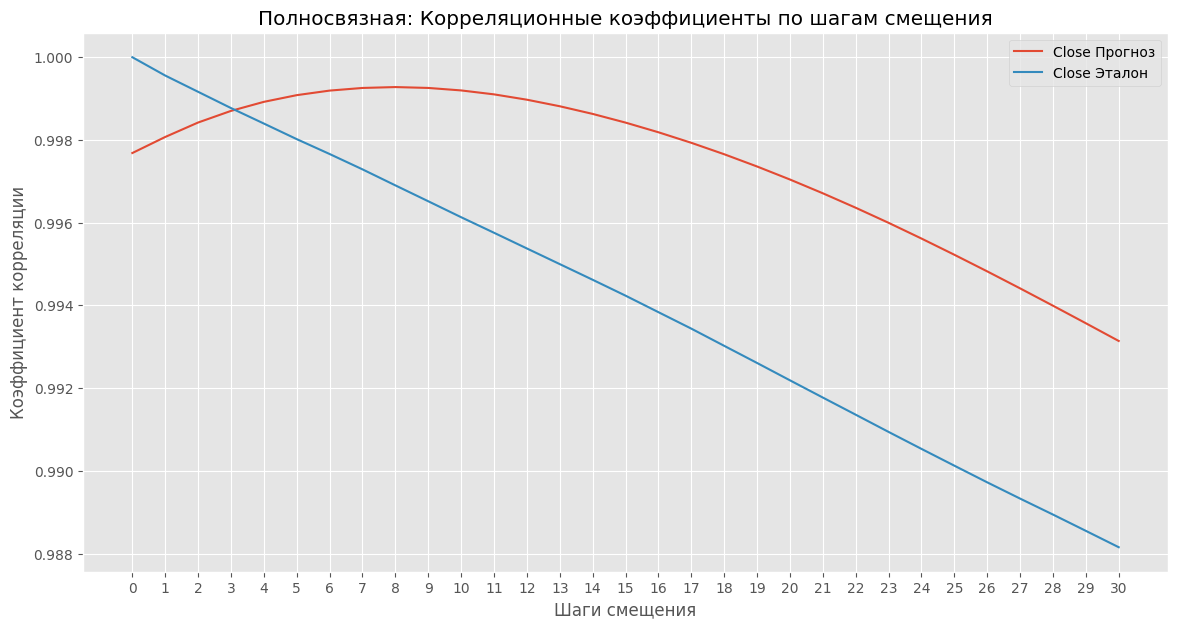

In [ ]:
# Обучение модели 3x50 эпох
train_eval_net(model_dense, train_datagen, val_datagen, [(50, Adam(learning_rate=1e-4)),
                                                         (50, Adam(learning_rate=1e-5)),
                                                         (50, Adam(learning_rate=1e-6))],
               x_test, y_test, y_scaler, title='Полносвязная')

In [34]:




# Создание генератора для обучения
train_datagen_10 = TimeseriesGenerator(x_data_train[:-10],
                                    y_data_train_10,
                                    length=SEQ_LEN,
                                    stride=1,
                                    sampling_rate=1,
                                    batch_size=BATCH_SIZE)

# Аналогичный генератор для валидации при обучении
val_datagen_10 = TimeseriesGenerator(x_data_test[:-10],
                                  y_data_test_10,
                                  length=SEQ_LEN,
                                  stride=1,
                                  sampling_rate=1,
                                  batch_size=BATCH_SIZE)

# Генератор тестовой выборки, генерирует один батч на всю выборку
test_datagen_10 = TimeseriesGenerator(x_data_test[:-10],
                                   y_data_test_10,
                                   length=SEQ_LEN,
                                   stride=1,
                                   sampling_rate=1,
                                   batch_size=x_data_test.shape[0])

# Формирование тестовой выборки из генератора
x_test, y_test_10 = test_datagen_10[0]

In [59]:
# Основные слои
from tensorflow.keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, Conv2D, LSTM, GlobalMaxPooling1D, MaxPooling1D, RepeatVector

print(train_datagen_10[0][0].shape)
print(y_data_test_10.shape)
# Входной слой
input = Input(shape=(train_datagen_10[0][0].shape[1:]))
# Преобразование в одномерный вектор
x = Flatten()(input)
# Повтор вектора несколько раз
x = RepeatVector(4)(x)
# Одномерная свертка
x = Conv1D(SEQ_LEN * 2, 5, padding='same', activation='relu')(x)
# Макспулинг и понижение размерности
x = MaxPooling1D(pool_size=2)(x)
# Преобразование в одномерный вектор
x = Flatten()(x)
# Повтор вектора несколько раз
x = RepeatVector(4)(x)
# Одномерная свертка
x = Conv1D(SEQ_LEN, 5, padding='same', activation='relu')(x)
# Макспулинг и понижение размерности
x = MaxPooling1D(pool_size=2)(x)
# Преобразование в одномерный вектор
x = Flatten()(x)
# Полносвязный слой
x = Dense(SEQ_LEN * 100, activation='relu')(x)
# Слой регуляризации
x = Dropout(0.4)(x)
# Финальный слой классификатора
x = Dense(y_data_test_10.shape[1], activation='linear')(x)

# Сборка модели из входа и выхода
model = Model(input, x)

(20, 300, 5)
(29390, 10)


In [60]:
model.compile(loss='mse', optimizer=Adam(learning_rate=1e-04))
# Фаза обучения модели
print(train_datagen_10[0][0][:5].shape)
history = model.fit(train_datagen_10,
                    epochs=6,
                    validation_data=val_datagen_10,
                    verbose=1)

(5, 300, 5)
Epoch 1/6
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 379s 17ms/step - loss: 0.0020 - val_loss: 3.5691e-05
Epoch 2/6
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 369s 16ms/step - loss: 2.2592e-04 - val_loss: 2.6509e-04
Epoch 3/6
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 369s 16ms/step - loss: 1.7105e-04 - val_loss: 1.8798e-04
Epoch 4/6
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 369s 16ms/step - loss: 1.5257e-04 - val_loss: 4.9870e-05
Epoch 5/6
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 370s 16ms/step - loss: 1.3972e-04 - val_loss: 1.2570e-04
Epoch 6/6
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 368s 16ms/step - loss: 1.2236e-04 - val_loss: 9.0853e-05


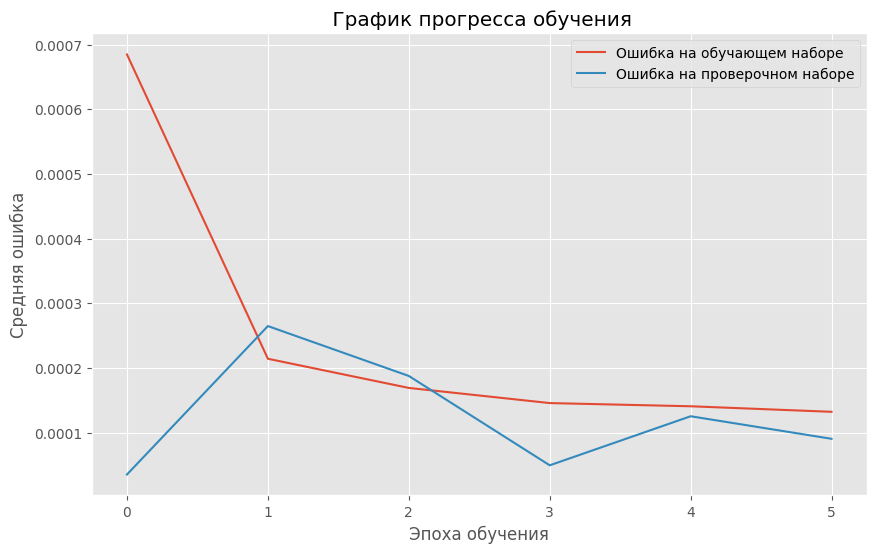

In [66]:
# Рисование графиков прошедшей фазы обучения
fig, (ax1) = plt.subplots(1, 1, figsize=(10, 6), sharex=True)
ax1.set_title(f' График прогресса обучения')
ax1.plot(history.history['loss'], label='Ошибка на обучающем наборе')
ax1.plot(history.history['val_loss'], label='Ошибка на проверочном наборе')
ax1.set_ylabel('Средняя ошибка')
ax1.legend()

# Указание показывать только целые метки шкалы оси x
fig.gca().xaxis.get_major_locator().set_params(integer=True)
plt.xlabel('Эпоха обучения')
plt.show()

In [67]:
# Получение денормализованного предсказания и данных базового ряда
y_pred, y_true = get_pred(model, x_test, y_test_10, y_scaler_10)


910/910 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [79]:
def show_predict2(y_pred, y_true, # прогноз данных и исходный ряд
                 start, # точка ряда, с которой начинается отрисовка графика
                 length, # количество точек для отрисовки графика
                 chn_list=[0], # список каналов данных для отрисовки (по умолчанию все)
                 chn_names=CHANNEL_Y, # список имен каналов данных
                 title=''):

    # Если список каналов пуст - отображаются все каналы
    if not chn_list:
        chn_list = list(range(y_true.shape[1]))

    # Построение графика по всем каналам данных
    plt.figure(figsize=(22, 6))
    #print(chn_list)
    for chn in chn_list:
        #print(chn, y_pred.shape, y_pred[:5])
        plt.plot(y_pred[start:start + length, chn],
                label=f'{chn_names[chn]} Прогноз')
        plt.plot(y_true[start:start + length, chn],
                label=f'{chn_names[chn]} Базовый')

    plt.title(title)
    plt.xlabel('Время')
    plt.ylabel('Данные')
    plt.legend()
    plt.show()

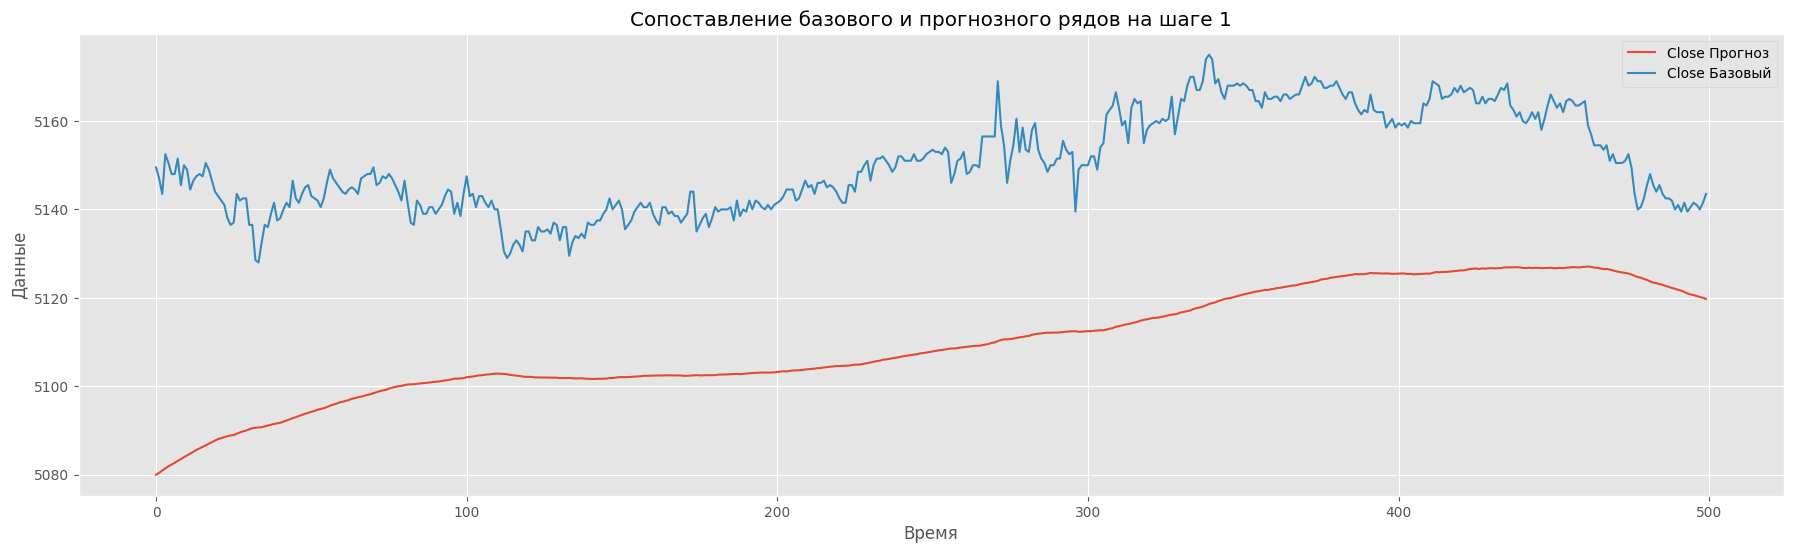

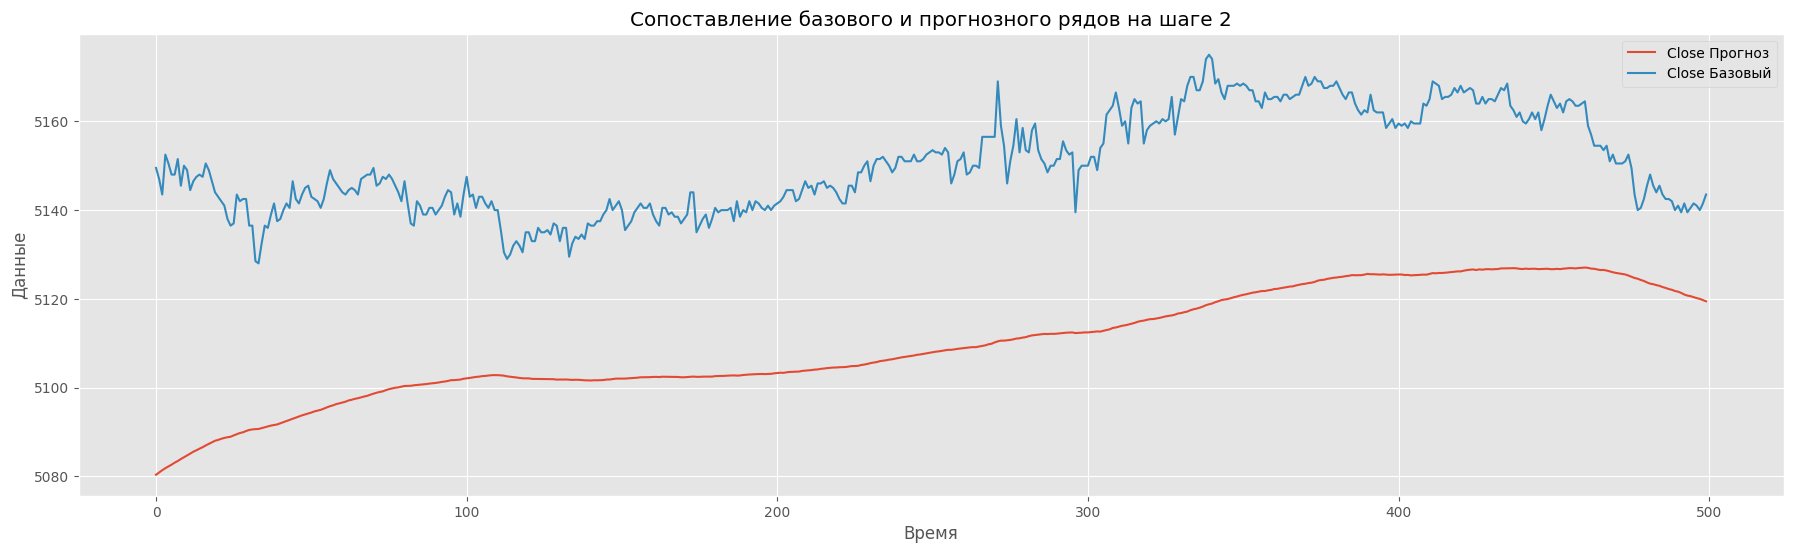

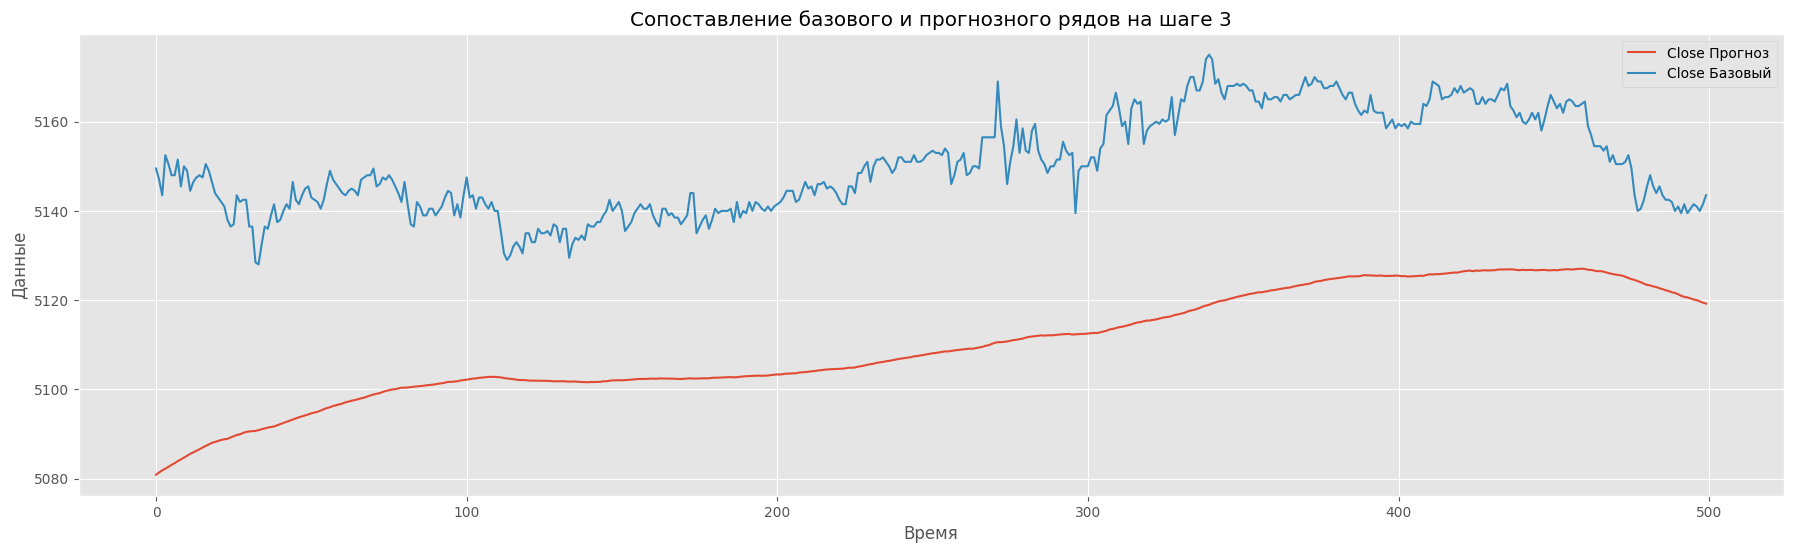

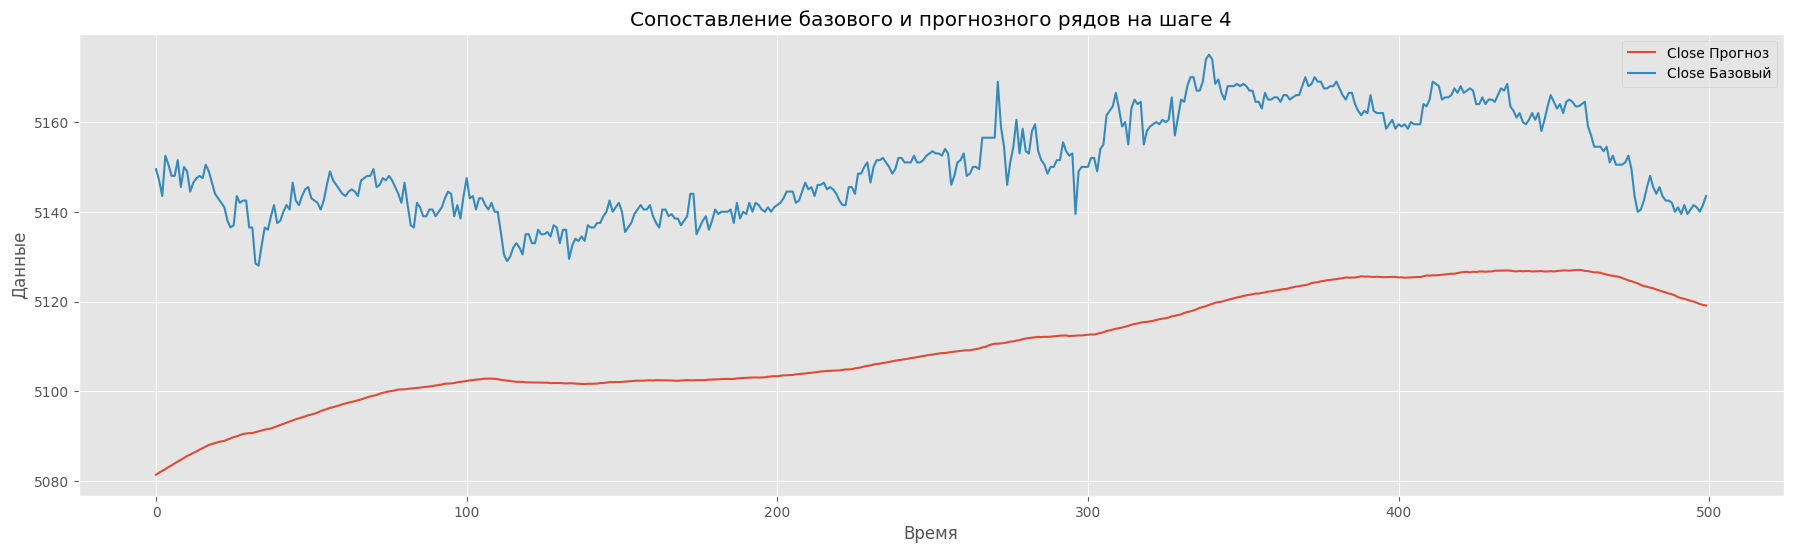

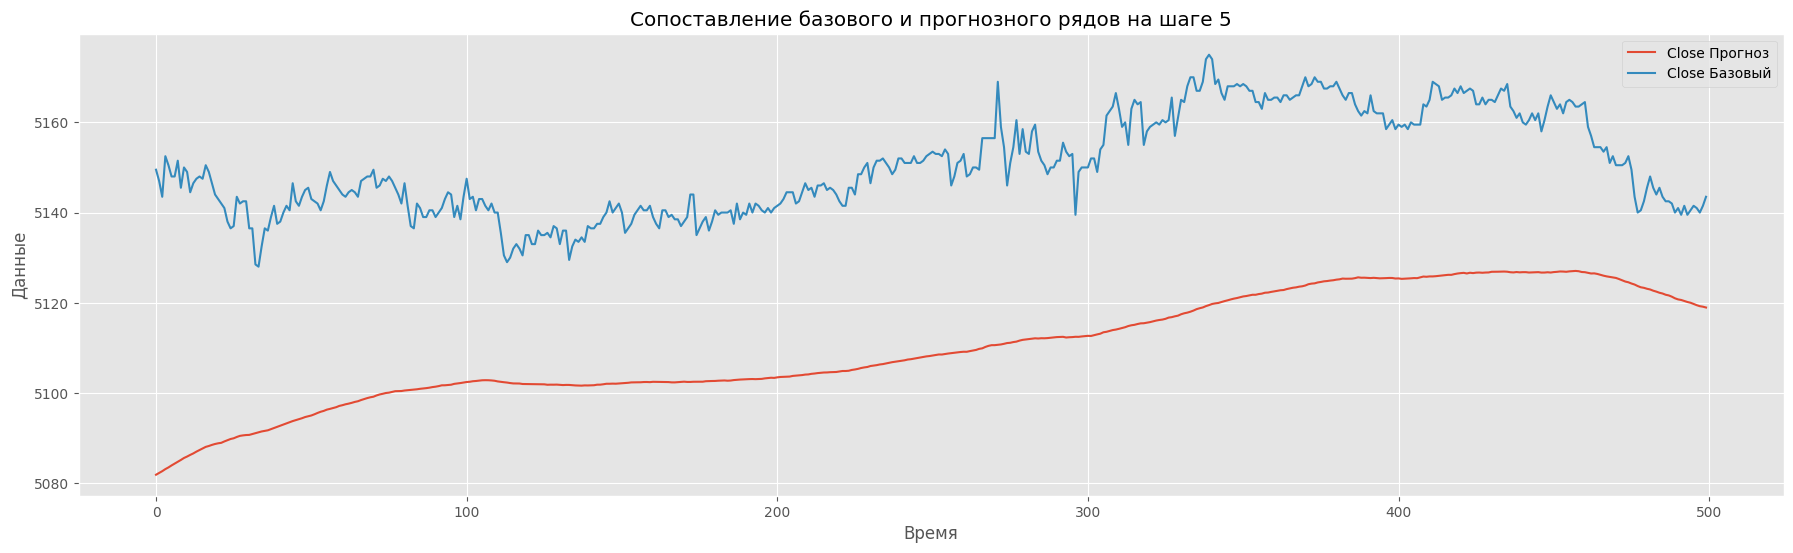

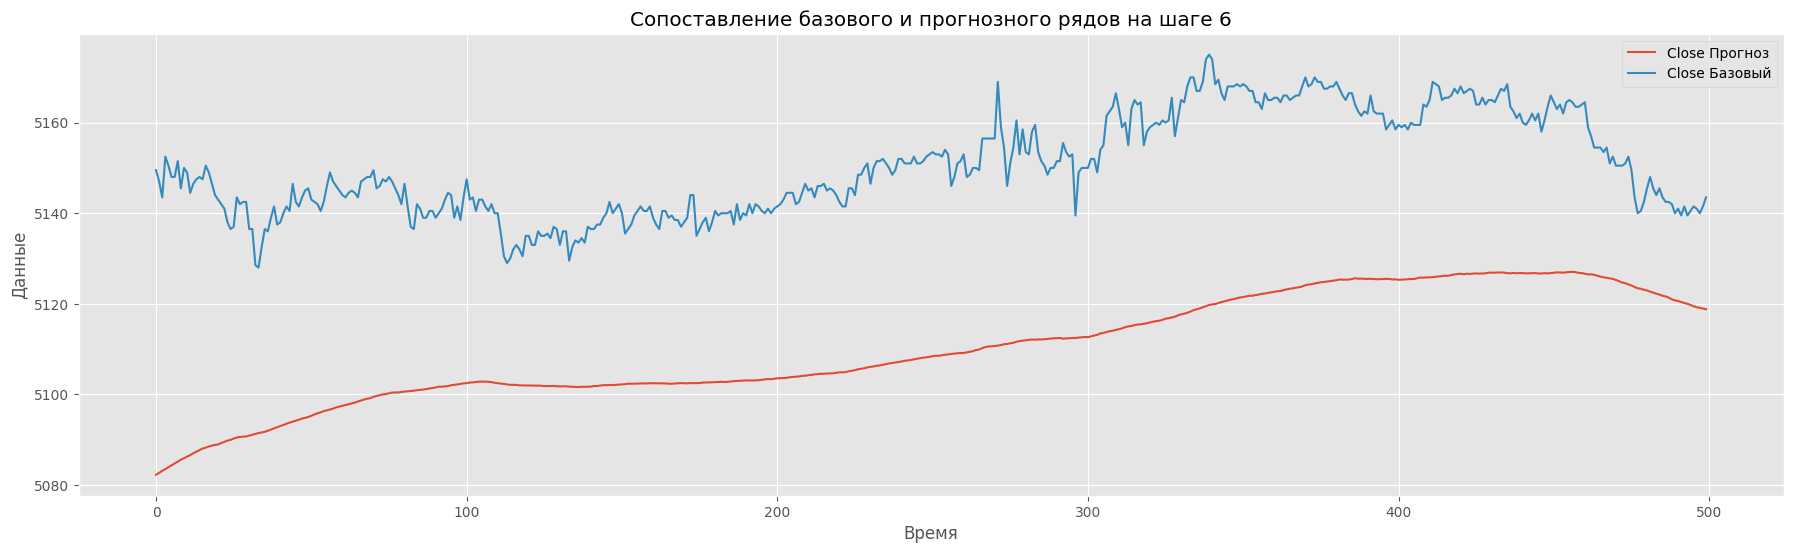

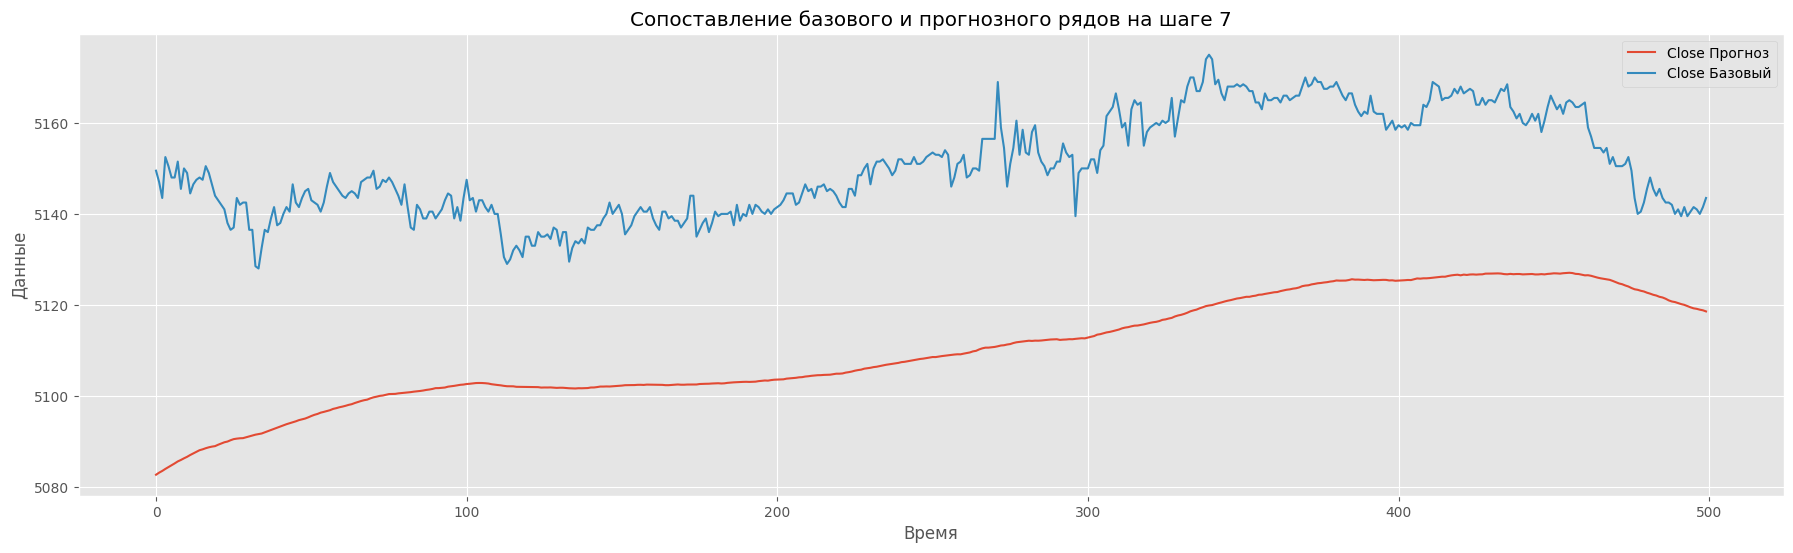

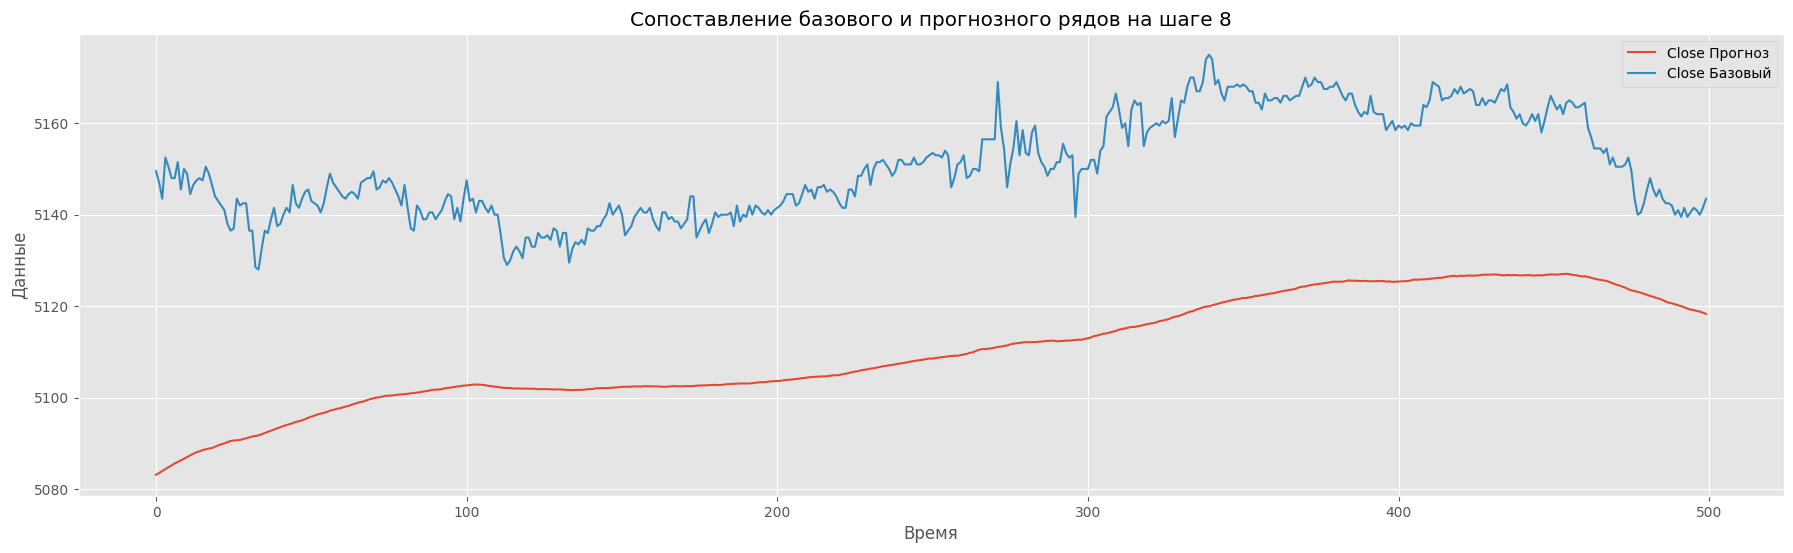

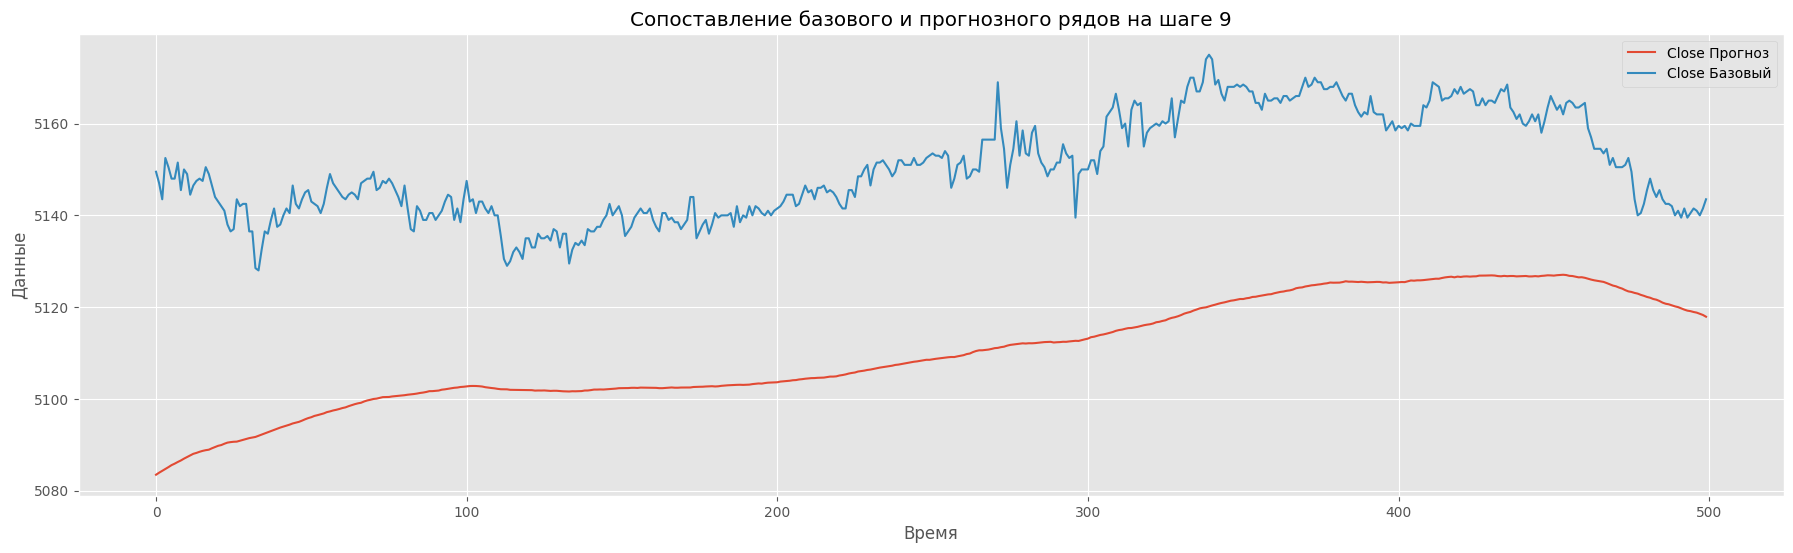

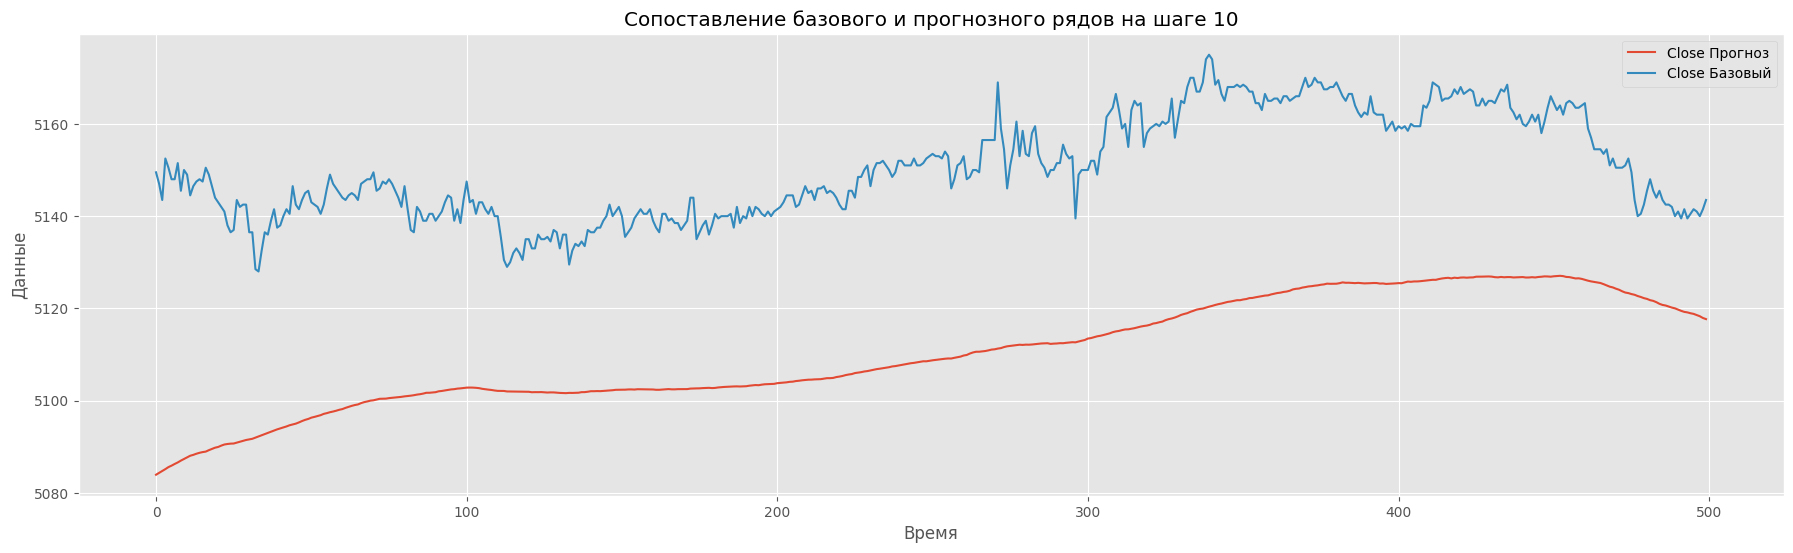

In [80]:
for i in range(1, 11):
  # Прогнозный ряд сдвигается на 1 шаг назад, так как предсказание делалось на 1 шаг вперед
  show_predict2(y_pred[i:], y_true[:-i], 0, 500,
              title=f'Сопоставление базового и прогнозного рядов на шаге {i}')